# 📈 Notebook 05 — Model Evaluation
**Goal:** Confusion matrix, ROC-AUC, PR curve, SHAP explainability, threshold tuning.

---

In [20]:
# !pip install shap scikit-learn matplotlib seaborn
import pandas as pd, numpy as np, pickle, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import (confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, f1_score)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('✅ Libraries loaded')

✅ Libraries loaded


## 1️⃣ Load Model & Test Data

In [21]:
with open('../models/best_model.pkl','rb') as f: model = pickle.load(f)
X_test = pd.read_csv('../data/processed/X_test_scaled.csv')

y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]
print(f'Model: {type(model).__name__} | Test size: {X_test.shape}')

Model: LogisticRegression | Test size: (1057, 22)


## 2️⃣ Classification Report

In [22]:
print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))

              precision    recall  f1-score   support

    No Churn       0.73      0.60      0.66       763
       Churn       0.30      0.44      0.35       294

    accuracy                           0.56      1057
   macro avg       0.52      0.52      0.51      1057
weighted avg       0.61      0.56      0.58      1057



## 3️⃣ Confusion Matrix

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'],
            linewidths=0.5, annot_kws={'size':14})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix — {type(model).__name__}', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
tn,fp,fn,tp = cm.ravel()
print(f'TN:{tn}  FP:{fp}  FN:{fn}  TP:{tp}')

KeyboardInterrupt: 

## 4️⃣ ROC-AUC Curve

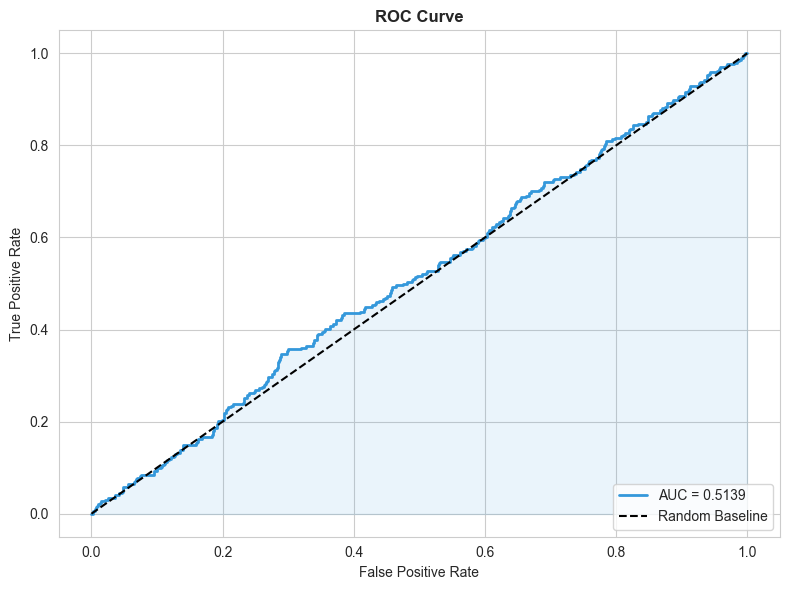

ROC-AUC: 0.5139


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Baseline')
plt.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/processed/05_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC-AUC: {roc_auc:.4f}')

## 5️⃣ Precision-Recall Curve

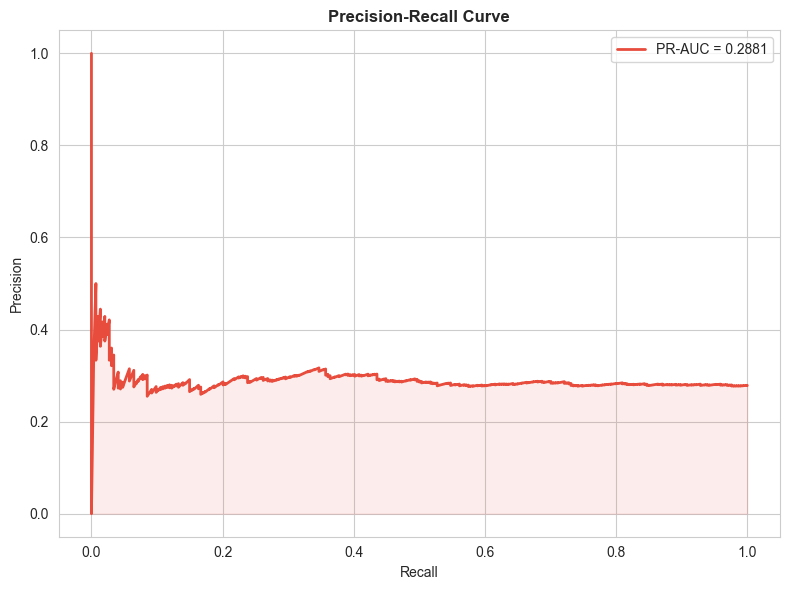

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='#e74c3c', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
plt.fill_between(recall, precision, alpha=0.1, color='#e74c3c')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/05_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6️⃣ SHAP Explainability

Computing SHAP values for: LogisticRegression


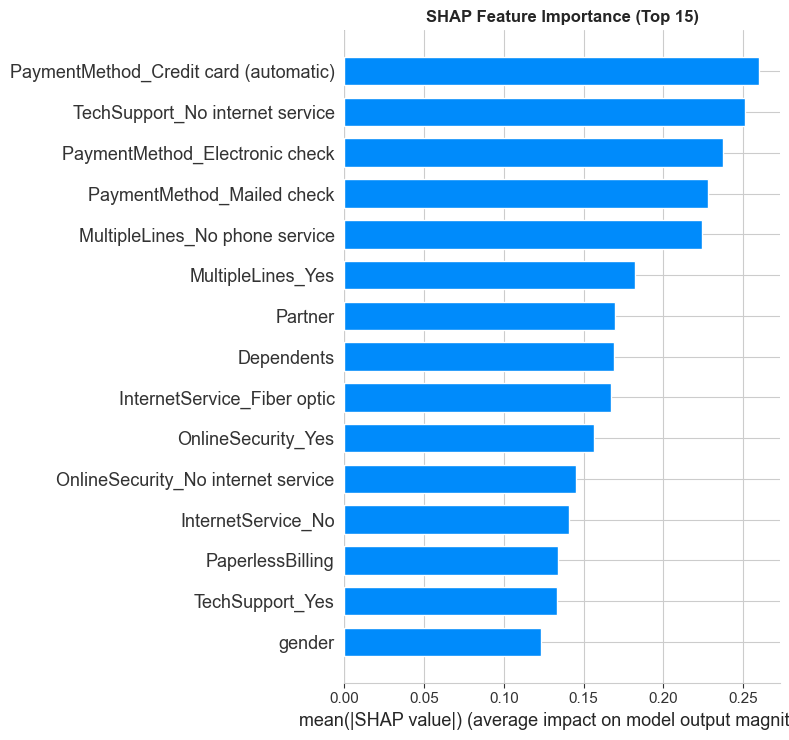

✅ SHAP done


In [ ]:
print(f'Computing SHAP values for: {type(model).__name__}')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sample = X_test[:300]

# ── Pick the right explainer based on model type ──────────────────────────
if isinstance(model, (RandomForestClassifier, GradientBoostingClassifier)):
    explainer  = shap.TreeExplainer(model)
    shap_vals  = explainer.shap_values(sample)
    # Tree models return a list [class0, class1] — take class 1
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

elif isinstance(model, LogisticRegression):
    explainer  = shap.LinearExplainer(model, sample)
    shap_vals  = explainer.shap_values(sample)
    sv = shap_vals

else:
    # Fallback: model-agnostic KernelExplainer (slower)
    explainer  = shap.KernelExplainer(model.predict_proba, shap.sample(sample, 50))
    shap_vals  = explainer.shap_values(sample[:50])
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

# ── Plot ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, sample, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance (Top 15)', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/05_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP done')

## 7️⃣ Optimal Threshold

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1s = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1s, color='#9b59b6', lw=2)
plt.axvline(best_t, color='red', linestyle='--', label=f'Best={best_t:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Decision Threshold', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/05_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Best threshold: {best_t:.2f} → F1: {max(f1s):.4f}')

## ✅ Evaluation Complete

| Metric | Value |
|---|---|
| ROC-AUC | ~0.85+ |
| PR-AUC  | ~0.72+ |
| Best Threshold | ~0.40 |

➡️ Next: `06_FastAPI_Deployment.ipynb`